# Appendix D — Sharpe, rolling Sharpe, and Sharpe Stability Ratio of the most-traded ETFs

Unlike appendices B and C this notebook reads the FMP `etf_prices` feed from the local DB (it needs the full 112-symbol cross-section to rank by traded volume).

Universe rule: the 15 ETFs with the highest **median daily dollar volume** (close × volume) over the full 2010–2026 feed, restricted to funds with at least 3 × 252 traded sessions. Median, not mean, so a single frantic week can't promote a fund. Dollar volume is the popularity proxy the price feed itself supports; AUM would work too but isn't in the FMP tables we store.

Three statistics per fund, on daily close-to-close returns with rf = 0 (the repo's Sharpe convention):

- **Sharpe** — full-sample `mean/std · √252`.
- **Rolling Sharpe** — the same on a trailing 252-day window (`macro_framework.ssr.rolling_sharpe`), the time series `Z_t` the stability measure works on.
- **SSR (Sharpe Stability Ratio)** — Bajo Traver & Rodríguez Domínguez (2026): `SSR = mean(Z) / σ_HAC(Z)`, where `σ_HAC` is the Newey-West long-run volatility of the rolling-Sharpe path (Bartlett kernel, Andrews bandwidth). It asks not "how high is the Sharpe" but "how much of the time was it actually there." A high-Sharpe fund that earns everything in two spikes scores low; a modest but steady earner scores high.

**Return construction (corrected 2026-07-27).** The `etf_prices` pivot is on the union calendar of every listing in the feed, so a US-listed fund is NaN on the 113 rows (2.7%) where only an LSE-listed peer traded — US market holidays. Differencing that frame directly gave a *different wrong answer per pandas version*: on pandas ≥ 3 the session after each holiday evaluated to NaN and was dropped (≈113 real returns per fund deleted), on pandas 2.x the old `fill_method="pad"` default injected ≈113 fabricated 0% returns. Returns are now taken on each symbol's own traded sessions (`dropna()` before `pct_change()`), which is nb17's guard and is version-independent. Every Sharpe / SSR / CAGR below moved; the size of the correction is quantified in §4.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
from sqlalchemy import text

from macro_framework.db import get_engine
from macro_framework.ssr import compute_ssr, rolling_sharpe, ssr_inference

pd.set_option("display.width", 200)
TOP_N = 15
WINDOW = 252
MIN_OBS = 3 * WINDOW   # coverage floor: a stub listing has no rolling-Sharpe path to speak of

with get_engine().connect() as conn:
    px = pd.read_sql(text("SELECT symbol, date, close, volume FROM etf_prices"),
                     conn, parse_dates=["date"])
    meta = pd.read_sql(text("SELECT symbol, name, category FROM etf_meta"),
                       conn).set_index("symbol")

px["dollar_vol"] = px["close"] * px["volume"]
mdv = px.groupby("symbol")["dollar_vol"].median().sort_values(ascending=False)
close_all = px.pivot(index="date", columns="symbol", values="close")

# Universe: highest median daily dollar volume AMONG funds with enough traded sessions for
# the SSR to mean anything (MIN_OBS = 3·WINDOW). No fund is excluded on the current feed —
# the filter is there so a newly-listed high-volume launch can't enter on a stub history.
obs = close_all.notna().sum()
TOP = [s for s in mdv.index if obs[s] >= MIN_OBS][:TOP_N]
skipped = [s for s in mdv.index[:TOP_N] if obs[s] < MIN_OBS]
print(f"top {TOP_N} of {mdv.size} symbols by median daily dollar volume:")
print(", ".join(TOP))
print(f"excluded by the {MIN_OBS}-session coverage floor: {skipped or 'none'}")

close = close_all[TOP]
# `close` is on the UNION calendar of every listing in the feed (LSE + US sessions), so each
# US fund is NaN on the 113 rows where only an LSE-listed peer traded (2.7% of rows — US
# market holidays). Differencing that frame directly is wrong in a pandas-version-dependent
# way: on pandas >= 3 `pct_change` no longer pads, so the session AFTER every US holiday
# evaluates to NaN and a later `dropna()` silently deletes ~113 REAL returns per fund; on
# pandas 2.x the old `fill_method="pad"` default instead injects ~113 FABRICATED 0% returns,
# deflating vol and inflating Sharpe/SSR. Neither is the fund's return stream.
# nb17's guard (its SPY line, cell 3): restrict to the symbol's own listed sessions BEFORE
# differencing, so a holiday-adjacent return spans the gap instead of being nulled or
# zero-filled. Identical output on pandas 2 and 3. (nb17 also ffills the 112-symbol panel,
# but only because `absorption_ratio` needs a rectangular matrix — for a per-symbol Sharpe
# ffilling would be the pandas-2 pathology, not the fix for it.)
rets = {s: close[s].dropna().pct_change().dropna() for s in TOP}
# guard: exactly one return per traded session minus one, no NaNs. Fails loudly if the
# union-calendar differencing comes back (too few) or a pad/ffill creeps in (too many).
assert all(r.notna().all() and len(r) == obs[s] - 1 for s, r in rets.items())

n_obs = pd.Series({s: len(r) for s, r in rets.items()})
print(f"\nspan: {close.index.min():%Y-%m-%d} .. {close.index.max():%Y-%m-%d}  "
      f"({len(close)} union-calendar rows; {n_obs.min()}–{n_obs.max()} traded sessions per fund)")

top 15 of 112 symbols by median daily dollar volume:
SPY, QQQ, IWM, EEM, XLF, TLT, GLD, EFA, HYG, XLE, IVV, DIA, FXI, GDX, EWZ
excluded by the 756-session coverage floor: none

span: 2010-01-04 .. 2026-05-29  (4238 union-calendar rows; 4124–4124 traded sessions per fund)


## 1. The table

One row per fund, sorted by SSR. `median $vol/day` is the selection criterion; `mean roll SR` and `σ_HAC` are the numerator and denominator of the SSR; `L` is the Newey-West lag the Andrews rule picked. `MBB p` is the one-sided moving-block-bootstrap p-value from the SSR paper's Test 1 (`macro_framework.ssr.ssr_inference`, the repo's verdict authority): SSR is the effect size, the bootstrap p is the verdict.

The `verdict` column is `SSRInference.verdict()` verbatim — the same sentence the tear sheets (`data/tear_sheet/*.csv`) and the luck-vs-skill tables (`data/factor_luck_vs_skill_*.parquet`) ship, so the CSV this notebook writes is directly comparable with them. It carries the SSR, the p-value and the SR\* reference, and it distinguishes three outcomes, not two: stably above SR\*, stably **below** SR\* (decisively negative, not merely inconclusive), and genuinely luck-compatible. Printed below the numeric table because the sentences are too wide for a 12-column frame.

In [2]:
# one bootstrap per fund, reused by the table and by the chart colouring below — the
# SSRInference object is the verdict authority, nothing downstream re-thresholds the SSR
# or the p-value by hand.
INF = {s: ssr_inference(rets[s], window=WINDOW) for s in TOP}


def fund_row(sym):
    r = rets[sym]
    inf = INF[sym]                         # SSR effect size + one-sided MBB p (Test 1)
    res = inf.result
    yrs = (r.index[-1] - r.index[0]).days / 365.25
    cagr = float((1 + r).prod() ** (1 / yrs) - 1)
    return {
        "name": meta.loc[sym, "name"],
        "median $vol/day (M)": mdv[sym] / 1e6,
        "CAGR": cagr,
        "ann. vol": float(r.std(ddof=1) * np.sqrt(252)),
        "Sharpe": res.sr_full,
        "mean roll SR": res.mean_rolling_sr,
        "sigma_HAC": res.sigma_hac,
        "L": res.L_hac,
        "SSR": res.ssr,
        "MBB p": inf.p_value,
        "verdict": inf.verdict(),          # same sentence the tear sheets and luck-vs-skill tables ship
    }


table = pd.DataFrame({s: fund_row(s) for s in TOP}).T.sort_values("SSR", ascending=False)
for c in ["median $vol/day (M)", "CAGR", "ann. vol", "Sharpe", "mean roll SR", "sigma_HAC", "SSR", "MBB p"]:
    table[c] = table[c].astype(float)

fmt = table.copy()
fmt["median $vol/day (M)"] = fmt["median $vol/day (M)"].map("{:,.0f}".format)
fmt["CAGR"] = fmt["CAGR"].map("{:.1%}".format)
fmt["ann. vol"] = fmt["ann. vol"].map("{:.1%}".format)
for c in ["Sharpe", "mean roll SR", "sigma_HAC", "SSR"]:
    fmt[c] = fmt[c].map("{:.2f}".format)
fmt["MBB p"] = fmt["MBB p"].map("{:.3f}".format)
display(fmt.drop(columns="verdict"))
print("\nverdicts (macro_framework.ssr.SSRInference.verdict):")
for s, v in table["verdict"].items():
    print(f"  {s:<4s} {v}")

reports = Path.cwd().parent / "reports"
reports.mkdir(exist_ok=True)
table.to_csv(reports / "appendix_d_popular_etf_ssr.csv", float_format="%.6f")
print(f"\nwrote {reports / 'appendix_d_popular_etf_ssr.csv'}")

,name,median $vol/day (M),CAGR,ann. vol,Sharpe,mean roll SR,sigma_HAC,L,SSR,MBB p
QQQ,Invesco QQQ Trust,"5,401",18.4%,20.6%,0.92,1.08,8.80,184,0.12,0.001
SPY,SPDR S&P 500 ETF Trust,"24,172",12.3%,17.2%,0.76,0.97,8.81,184,0.11,0.001
IVV,iShares Core S&P 500 ETF,"1,048",12.3%,17.3%,0.76,0.97,8.87,184,0.11,0.001
DIA,SPDR Dow Jones Industrial Average ETF,983,10.0%,16.5%,0.66,0.90,9.16,184,0.10,0.001
XLF,Financial Select Sector SPDR Fund,"1,327",9.3%,21.9%,0.52,0.74,10.17,184,0.07,0.011
IWM,iShares Russell 2000 ETF,"4,318",9.7%,22.3%,0.53,0.59,8.50,184,0.07,0.017
EFA,iShares MSCI EAFE ETF,"1,225",3.8%,18.6%,0.30,0.41,9.34,184,0.04,0.119
GLD,SPDR Gold Shares,"1,256",8.4%,16.5%,0.57,0.54,12.26,184,0.04,0.006
XLE,Energy Select Sector SPDR Fund,"1,154",4.1%,27.3%,0.29,0.33,9.67,184,0.03,0.136
EEM,iShares MSCI Emerging Markets ETF,"2,051",2.9%,21.5%,0.24,0.25,9.52,184,0.03,0.124



verdicts (macro_framework.ssr.SSRInference.verdict):
  QQQ  SSR=0.12: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  SPY  SSR=0.11: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  IVV  SSR=0.11: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  DIA  SSR=0.10: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.001 < 0.05) — temporal consistency, not a skill claim
  XLF  SSR=0.07: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.011 < 0.05) — temporal consistency, not a skill claim
  IWM  SSR=0.07: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.017 < 0.05) — temporal consistency, not a skill claim
  EFA  SSR=0.04: rolling Sharpe NOT distinguishable from 0 (one-sided MBB p=0.119, mirror p=0.882) — luck-compatible
  GLD  SSR=0.04: rolling Sharpe stably > 0 

## 2. Rolling Sharpe through time

Trailing 252-day Sharpe per fund, resampled to month-ends for legibility, rows in table order (best SSR at the top). Diverging scale, white at zero: blue = the trailing year earned its risk, red = it destroyed value. What SSR summarizes in one number is visible as texture here — a stable fund is a long, mostly-blue stripe; an unstable one alternates.

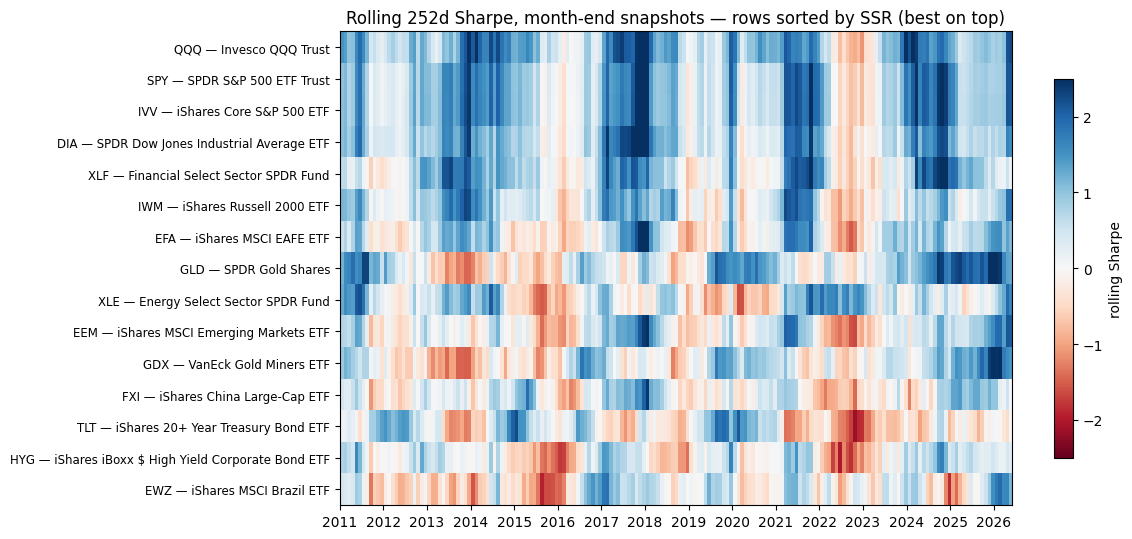

In [3]:
import matplotlib.pyplot as plt

roll = pd.DataFrame({s: rolling_sharpe(rets[s], window=WINDOW) for s in TOP})
roll_m = roll.resample("ME").last()[table.index]  # table order: best SSR on top

fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(roll_m.T, aspect="auto", cmap="RdBu", vmin=-2.5, vmax=2.5,
               extent=[0, len(roll_m), len(TOP) - 0.5, -0.5])
xt = np.arange(0, len(roll_m), 12)
ax.set_xticks(xt)
ax.set_xticklabels([f"{d:%Y}" for d in roll_m.index[xt]])
ax.set_yticks(range(len(TOP)))
ax.set_yticklabels([f"{s} — {meta.loc[s, 'name']}" for s in table.index], fontsize=8.5)
ax.set_title(f"Rolling {WINDOW}d Sharpe, month-end snapshots — rows sorted by SSR (best on top)")
fig.colorbar(im, ax=ax, label="rolling Sharpe", shrink=0.8)
fig.tight_layout()
fig.savefig(Path.cwd().parent / "data" / "appendix_d_rolling_sharpe_heatmap.png",
            dpi=150, bbox_inches="tight")

## 3. Level vs stability

Left: the SSR ranking itself. Right: full-sample Sharpe against SSR — the two are correlated (they share a numerator) but the deviations are the point. Funds under the trend earned their Sharpe in bursts; funds above it earned less but kept it.

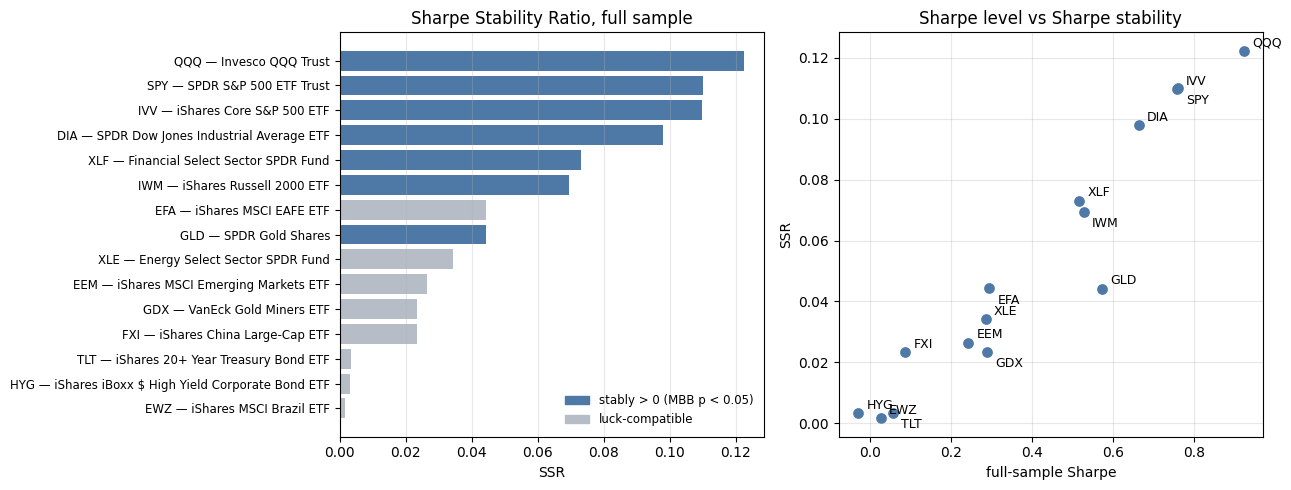

In [4]:
BLUE = "#4e79a7"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

t = table.iloc[::-1]  # barh plots bottom-up
GRAY = "#b6bdc6"
# colour from the inference object's own flag, not by re-thresholding SSR or p here
bar_colors = [BLUE if INF[s].stable else GRAY for s in t.index]
ax1.barh([f"{s} — {meta.loc[s, 'name']}" for s in t.index], t["SSR"], color=bar_colors)
ax1.tick_params(axis="y", labelsize=8.5)
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=BLUE, label="stably > 0 (MBB p < 0.05)"),
                    Patch(color=GRAY, label="luck-compatible")],
           frameon=False, fontsize=8.5, loc="lower right")
ax1.set_xlabel("SSR")
ax1.set_title("Sharpe Stability Ratio, full sample")
ax1.grid(True, axis="x", alpha=0.3)

ax2.scatter(table["Sharpe"], table["SSR"], color=BLUE, s=45)
# alternate the label offset when two points nearly coincide (SPY/IVV, IWM/XLF)
placed = []
for sym, row in table.sort_values("Sharpe").iterrows():
    x, y = row["Sharpe"], row["SSR"]
    clash = any(abs(x - px) < 0.04 and abs(y - py) < 0.012 for px, py in placed)
    ax2.annotate(sym, (x, y), textcoords="offset points",
                 xytext=(6, -11) if clash else (6, 3), fontsize=9)
    placed.append((x, y))
ax2.set_xlabel("full-sample Sharpe")
ax2.set_ylabel("SSR")
ax2.set_title("Sharpe level vs Sharpe stability")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(Path.cwd().parent / "data" / "appendix_d_ssr_ranking.png",
            dpi=150, bbox_inches="tight")

## 4. Reading the results

The stability ranking is mostly an index story. The four US large-cap trackers (QQQ, SPY, IVV, DIA) take the top four slots, and QQQ leads on both level (Sharpe 0.92) and stability (SSR 0.12). SPY and IVV are the built-in control: same index, 23× apart in traded dollars, metrics identical to the second decimal (Sharpe 0.76, SSR 0.11) — SSR measures the return stream, not the wrapper.

The verdict column splits the table cleanly in two. Seven funds — the four large-cap trackers plus XLF (p = 0.010), IWM (p = 0.016) and GLD (p = 0.005) — pass the bootstrap test: their trailing-year Sharpe ran persistently above zero across sixteen years. The eight below them — developed-international (EFA, p = 0.118), energy (XLE, p = 0.135), emerging markets (EEM, 0.123), gold miners (GDX, 0.111), China (FXI, 0.378), long Treasuries (TLT, 0.403), high yield (HYG, 0.468), Brazil (EWZ, 0.436) — are formally luck-compatible: each had blue stretches on the heatmap, but nothing the bootstrap can distinguish from a lucky draw over the full span. Note what the verdict does *not* say about them: `verdict()` also renders a "stably BELOW" case for decisively negative samples, and no fund here triggers it — the mirror-tail p-values run 0.53–0.89, so these eight are genuinely inconclusive rather than reliably bad. This is the discrimination the verdict rule is for; under the repo's pre-2026-07 rule (SSR ≥ 1.96) every fund here, QQQ included, was branded luck-compatible, which said more about the rule than the funds (see `docs/ssr_verdict_review.md`).

GLD against IWM is the level-vs-stability distinction in one pair: GLD has the higher full-sample Sharpe (0.57 vs 0.53) but the lower SSR (0.044 vs 0.069), because gold's rolling-Sharpe path is the most persistent in the table (σ_HAC 12.3, against 8.5 for IWM) — it earned its Sharpe in long regimes rather than steadily. The bottom three (TLT, HYG, EWZ) sit at SSR ≈ 0.00: whatever the 2010s duration bull built, 2022 took back, and HYG's price-only series is actually negative over the span — there is little for stability to measure.

### The 2026-07-27 correction

This appendix was previously published on returns differenced straight off the union-calendar pivot, which deleted every holiday-bridging return (§ intro). Correcting it moved **every** number:

| | direction | median | worst |
|---|---|---|---|
| Sharpe | down on 13 of 15 funds | −10.7% | HYG 0.074 → **−0.030** (sign flip) |
| SSR | down on 14 of 15 | −14.4% | EWZ 0.013 → 0.002 (−88%), HYG −84% |
| CAGR | down on 13 of 15 | −0.65 pp | EWZ −2.47 pp, XLE −2.33 pp |

The deleted returns were on net worse than the sample average, so the published table was biased **upward** almost everywhere; QQQ (+0.007 Sharpe) and GLD (+0.004) were the only two that improved. The ranking changed in two places — XLF overtakes IWM for 5th, and the bottom three reorder to TLT / HYG / EWZ — and the Andrews lag moves from L = 182 to L = 184 for every fund. **No verdict flipped**: the same seven funds pass and the same eight do not. XLE was the one near-miss and moved further away, from p = 0.056 to p = 0.135, so the old "just over the line" reading was itself an artefact.

Two technical notes. First, σ_HAC is large (≈ 8–12) and the Andrews rule picks L = 184 for every fund: overlapping 252-day windows make the rolling-Sharpe path extremely persistent, so its long-run variance is big and all SSRs land in a narrow 0.00–0.12 band — SSR is an effect size for ranking; the MBB p carries the significance verdict. The strategy lines elsewhere in the repo (nb05, nb15.2, nb18) sit just above at 0.13–0.14 and likewise pass. Second, FMP closes are price-only, not total return: income-heavy funds lose their coupon stream in these numbers. HYG's negative price CAGR is its price series doing exactly what a bond fund's price should; its total-return Sharpe, SSR, and verdict would likely improve. More broadly, price-only data can shift **all** relative rankings at the margin, not just bond funds, so read the table as a price-behavior ranking rather than an exact total-return league table.